In [7]:
#import numpy as np
#import pandas as pd
#
## 1) Alfabeto (ajústalo si tienes símbolos extra)
#AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")  # 20 estándar
#UNK = "X"                                   # token para desconocidos
#ALPH = AMINO_ACIDS + [UNK]
#A = len(ALPH)
#
## 2) Secuencias
#seqs = df_inds["sequence"].astype(str).tolist()
#L = len(seqs[0])
#assert all(len(s) == L for s in seqs), "Todas las secuencias deben tener la misma longitud"
#
## 3) Mapear letras -> índices
#idx = {aa:i for i,aa in enumerate(ALPH)}
#
## 4) Convertir a matriz (N, L) de índices
##    Si aparece una letra fuera del alfabeto, la mandamos a UNK
#def seq_to_idx(s):
#    return [idx.get(ch, idx[UNK]) for ch in s]
#
#arr_idx = np.array([seq_to_idx(s) for s in seqs], dtype=int)  # (N, L)
#N = arr_idx.shape[0]
#
## 5) One-hot: (N, L, A) -> (N, L*A)
#one_hot = np.eye(A, dtype=int)[arr_idx]        # (N, L, A)
#one_hot_flat = one_hot.reshape(N, L*A)         # (N, L*A)
#
## 6) Columnas
#cols = [f"pos{pos+1}_{aa}" for pos in range(L) for aa in ALPH]
#
## 7) DataFrame
#df_onehot = pd.DataFrame(one_hot_flat, columns=cols, index=df_inds.index)
#
## 8) Unir con tus métricas
#df_encoded = pd.concat([df_inds[['dG_separated/dSASAx100', 'f_attr']].reset_index(drop=True), df_onehot.reset_index(drop=True)], axis=1)
#df_encoded

In [8]:
#from xgboost import XGBRegressor
#from sklearn.preprocessing import LabelEncoder
#
## Preparamos los datos
#X = df_encoded.drop(columns=['dG_separated/dSASAx100', 'f_attr'])
#y_fattr = df_encoded['f_attr'].astype(float)
#y_dg = df_encoded['dG_separated/dSASAx100'].astype(float)
#
## Modelo para f_attr
#xgb_fattr = XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)
#xgb_fattr.fit(X, y_fattr)
#importances_fattr = pd.Series(xgb_fattr.feature_importances_, index=X.columns).sort_values(ascending=False)
#
## Modelo para dG_separated/dSASAx100
#xgb_dg = XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)
#xgb_dg.fit(X, y_dg)
#importances_dg = pd.Series(xgb_dg.feature_importances_, index=X.columns).sort_values(ascending=False)
#
#importances_fattr.head(15), importances_dg.head(15)

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df_sc = pd.read_csv("tests/test3_2mobj/statistics/run15_scfile.csv")
df_sc.drop(columns=['sequence'], inplace=True)
df_sc = df_sc.apply(pd.to_numeric, errors="coerce")
df_sc

,total_score,complex_normalized,dG_cross,dG_cross/dSASAx100,dG_separated,dG_separated/dSASAx100,dSASA_hphobic,dSASA_int,dSASA_polar,delta_unsatHbonds,...,rama_prepro,ref,sc_value,side1_normalized,side1_score,side2_normalized,side2_score,yhh_planarity,generation,nmut
0,-600.383,-2.232,-58.300,-2.777,-53.422,-2.545,993.688,2099.250,1105.562,17.0,...,37.109,174.202,0.633,-2.536,-78.608,-2.635,-97.503,0.312,14,5
1,-605.329,-2.249,-52.551,-2.637,-48.579,-2.438,1059.812,1992.660,932.848,18.0,...,37.673,182.161,0.626,-2.578,-74.772,-2.776,-97.155,0.221,14,6
2,-590.624,-2.194,-44.382,-2.491,-36.106,-2.027,923.155,1781.359,858.204,17.0,...,33.035,175.807,0.617,-2.647,-74.129,-2.648,-79.447,0.185,14,6
3,-606.406,-2.254,-60.806,-2.916,-53.832,-2.582,1097.278,2085.184,987.906,17.0,...,36.505,178.992,0.624,-2.616,-78.494,-2.656,-95.634,0.522,14,9
4,-619.026,-2.301,-55.233,-2.799,-49.821,-2.525,974.067,1973.322,999.255,15.0,...,36.415,178.109,0.589,-2.543,-73.742,-2.753,-93.588,0.228,14,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,-589.194,-2.194,-48.621,-2.397,-44.279,-2.183,1014.947,2028.120,1013.174,19.0,...,46.276,173.331,0.582,-2.215,-68.663,-3.005,-111.198,0.338,1,1
476,-591.711,-2.200,-42.773,-2.196,-39.927,-2.050,968.100,1947.647,979.547,17.0,...,36.707,175.724,0.547,-2.364,-70.920,-3.014,-102.472,0.719,1,1
477,-592.215,-2.200,-44.883,-2.346,-41.035,-2.145,864.764,1913.152,1048.388,16.0,...,37.943,176.823,0.601,-2.559,-71.659,-2.912,-96.087,0.682,1,1
478,-598.681,-2.226,-44.413,-2.294,-42.416,-2.191,966.968,1936.092,969.124,20.0,...,34.709,173.243,0.573,-2.516,-70.438,-2.946,-103.108,0.915,1,1


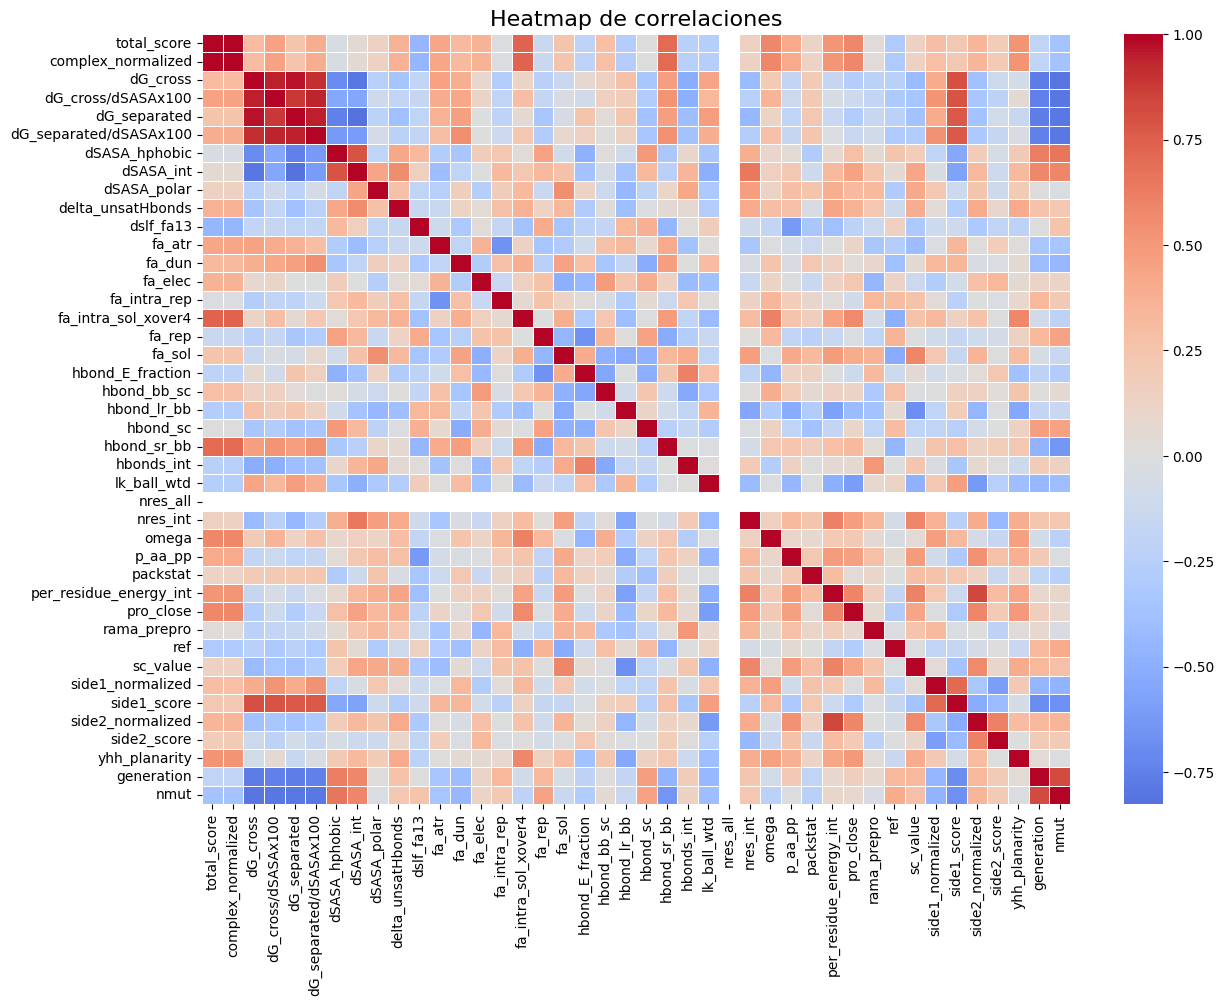

In [10]:
import seaborn as sns

corr = df_sc.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)
plt.title("Heatmap de correlaciones", fontsize=16)
plt.show()

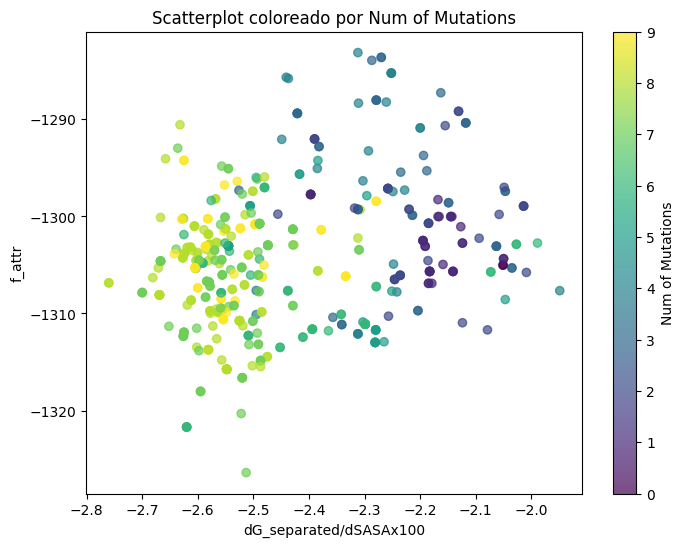

In [11]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_sc['dG_separated/dSASAx100'], df_sc['fa_atr'], c=df_sc['nmut'], cmap='viridis', alpha=0.7)
plt.xlabel('dG_separated/dSASAx100')
plt.ylabel('f_attr')
plt.title('Scatterplot coloreado por Num of Mutations')
plt.colorbar(scatter, label='Num of Mutations')
plt.show()

In [12]:
df_hof = pd.read_csv("tests/test3_2mobj/statistics/run15_hallofame.csv")
df_hof[['dG_separated/dSASAx100', 'fa_atr']] = df_hof['fitness'].str.split(",",expand=True).astype(float)
df_hof.drop(columns=['fitness'], inplace=True)
df_hof.head()

,generation,id,father,nmut,pdb_file,sequence,dG_separated/dSASAx100,fa_atr
0,3,3-61,2-41,3,../output/run15/g3/g3_13_relaxed.pdb,GYSYNTSVSGGSYNMEYLNATSYECFAGSNFYSGVGPT,-2.526,-1297.326
1,4,4-69,3-50,4,../output/run15/g4/g4_8_relaxed.pdb,GYSYNISVSGGSYNMDYLNKTAYECFHGSNFYSGVGPT,-2.495,-1307.637
2,4,4-76,1-22,3,../output/run15/g4/g4_9_relaxed.pdb,RYSYNTSVSGGSYNMGYLNRTSYECFTGSNFYSGVGPT,-2.357,-1310.402
3,2,2-45,1-22,3,../output/run15/g2/g2_8_relaxed.pdb,RYSYNTSVSGGSYNMGYLNRTSYECFSGSNFYSGVGPT,-2.341,-1311.144
4,3,3-56,2-45,4,../output/run15/g3/g3_0_relaxed.pdb,RYSYNTSVSGGSYKMGYLNRTSYECFSGSNFYSGVGPT,-2.312,-1312.099


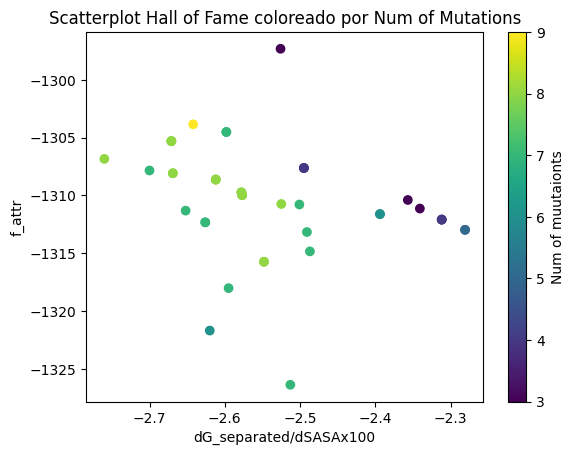

In [13]:
scatter_hof = plt.scatter(x=df_hof['dG_separated/dSASAx100'], y = df_hof['fa_atr'], c=df_hof['nmut'])
plt.title('Scatterplot Hall of Fame coloreado por Num of Mutations')
plt.xlabel('dG_separated/dSASAx100')
plt.ylabel('f_attr')
plt.colorbar(scatter_hof, label='Num of muutaionts')
plt.show()

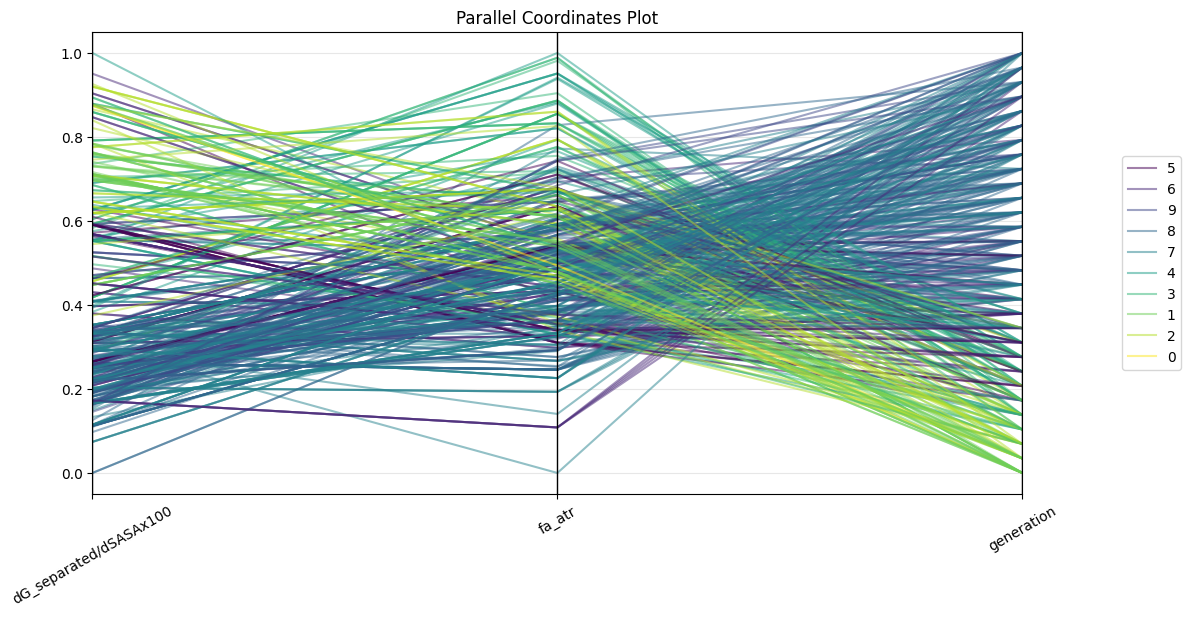

In [14]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

cols_to_plot = [
    'dG_separated/dSASAx100',
    'fa_atr',
    "generation",
    "nmut"
]

cols_to_plot_num = cols_to_plot[:-1]

scaler = MinMaxScaler()
df_sc[cols_to_plot_num] = scaler.fit_transform(df_sc[cols_to_plot_num])

# Hacemos el plot
plt.figure(figsize=(12,6))
parallel_coordinates(
    df_sc[cols_to_plot], 
    class_column="nmut", 
    colormap=plt.cm.viridis, 
    alpha=0.5
)
plt.title("Parallel Coordinates Plot")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.show()


In [15]:
df_single = pd.read_csv("tests/test2_1mobj/statistics/run15_individuals.csv")
df_single

,generation,id,father,nmut,pdb_file,fitness,sequence
0,0,0,Original,0,../output/run15/g0/g0_00_relaxed.pdb,-2.050,GYSYNTSVSGGSYNMDYLNRTSYECFNGSNFYSGVGPT
1,0,0-1,0,1,../output/run15/g0/g0_01_relaxed.pdb,-2.277,GYSYNTSVSGGSYNMDYLNRTTYECFNGSNFYSGVGPT
2,0,0-2,0,1,../output/run15/g0/g0_02_relaxed.pdb,-2.122,GYSYNTSVSGGSYNMGYLNRTSYECFNGSNFYSGVGPT
3,0,0-3,0,1,../output/run15/g0/g0_03_relaxed.pdb,-2.087,GYSYNTSVSGGSYNMDYLNRTLYECFNGSNFYSGVGPT
4,0,0-4,0,1,../output/run15/g0/g0_04_relaxed.pdb,-2.353,GYSYNTSVSGGSYNMSYLNRTSYECFNGSNFYSGVGPT
...,...,...,...,...,...,...,...
315,19,18-56,15-11,6,../output/run15/g19/g19_11_relaxed.pdb,-2.664,GYSYNDSVSGGSYNMAYLNGTSSECFHGSPFYSGVGPT
316,19,19-73,18-51,6,../output/run15/g19/g19_12_relaxed.pdb,-2.633,GYSYNTSVSGGSYNMSYLNSTASECFAGSAFYSGVGPT
317,19,19-69,17-39,8,../output/run15/g19/g19_13_relaxed.pdb,-2.609,GCSYNSSVSGGSYNMSYLNTTACECFAGSAFYSGVGPT
318,19,19-70,15-5,6,../output/run15/g19/g19_14_relaxed.pdb,-2.608,GYSYNTSVSGGSYNMSYLNSTAGECFAGSAFYSGVGPT


In [16]:
best_per_gen = df_single.loc[df_single.groupby("generation")["fitness"].idxmax()]
best_per_gen

,generation,id,father,nmut,pdb_file,fitness,sequence
0,0,0,Original,0,../output/run15/g0/g0_00_relaxed.pdb,-2.050,GYSYNTSVSGGSYNMDYLNRTSYECFNGSNFYSGVGPT
17,1,0-13,0,1,../output/run15/g1/g1_1_relaxed.pdb,-2.214,GYSYNTSVSGGSYNMDYLNRTGYECFNGSNFYSGVGPT
45,2,2-42,0-6,2,../output/run15/g2/g2_13_relaxed.pdb,-2.232,GYSYNTSVSGGSYNMAYLNRTSYECFHGSNFYSGVGPT
63,3,1-20,0-4,2,../output/run15/g3/g3_15_relaxed.pdb,-2.302,GYSYNNSVSGGSYNMSYLNRTSYECFNGSNFYSGVGPT
74,4,3-58,1-26,3,../output/run15/g4/g4_10_relaxed.pdb,-2.351,GYSYNVSVSGGSYNMSYLNRTAYECFNGSNFYSGVGPT
92,5,4-66,2-32,3,../output/run15/g5/g5_12_relaxed.pdb,-2.398,GYSYNTSVSGGSYNMSYLNKTSYECFAGSNFYSGVGPT
109,6,5-14,4-75,4,../output/run15/g6/g6_13_relaxed.pdb,-2.431,GYSYNTSVSGGSYNMNYLNATCRECFNGSNFYSGVGPT
122,7,7-46,6-29,6,../output/run15/g7/g7_10_relaxed.pdb,-2.527,GYSYNISVSGGSYNMAYLNGTSCECFHGSHFYSGVGPT
136,8,7-44,5-6,4,../output/run15/g8/g8_8_relaxed.pdb,-2.531,GYSYNTSVSGGSYNMNYLNTTCNECFNGSNFYSGVGPT
148,9,9-72,7-44,5,../output/run15/g9/g9_4_relaxed.pdb,-2.544,GYSYNVSVSGGSYNMNYLNTTCNECFNGSNFYSGVGPT


In [17]:
import os
import shutil
import pandas as pd

dst_path = "best_individuals"
pdb_folder = os.path.join(dst_path, "pdb")
sc_folder = os.path.join(dst_path, "sc")
os.makedirs(dst_path, exist_ok=True)
os.makedirs(pdb_folder, exist_ok=True)
os.makedirs(sc_folder, exist_ok=True)

for idx, individual in best_per_gen.iterrows():

    pdb_file = os.path.join("tests/test2_1mobj/", individual['pdb_file'].replace("../output/", ""))
    pdbsc_file = pdb_file + '.sc'

    shutil.copy(pdb_file, pdb_folder)
    shutil.copy(pdbsc_file, sc_folder)

best_per_gen_copy = best_per_gen.copy()
best_per_gen_copy['pdb_file'] = best_per_gen_copy['pdb_file'].str.replace("../output/run15/", "", regex=False)
best_per_gen_copy.to_csv(dst_path+"/best.csv", index=False)

In [4]:
import pandas as pd

# Cargar el archivo Excel
df = pd.read_excel("scenarios/test04/MSA_matrix.xlsx")
df = df.replace("-", 0.0)
# Guardar como TSV
df.to_csv("scenarios/test04/MSA_matrix.tsv", sep="\t", index=False)

/tmp/ipykernel_46958/769166694.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", 0.0)
